# 02 — Automated Health Card Report Generation

**Input:** `Sehore_WaterBody_Health_Card_FINAL.csv` (from `01_revival_strategy_mapping.ipynb`)

**Output:** `Sehore_Water_Body_Health_Card_Report.pdf` — a single consolidated PDF report

**Pattern:** profile the data → generate narrative text per entry → assemble PDF.
Same structure as Insight Engine (profiler → LLM analyst → chart engine → narrator →
report builder), simplified to a notebook. Narrative generation here is
**template-based by default** (deterministic, no API key needed, always works) —
an optional LLM-enhanced version using the Groq pattern from Insight Engine is
included at the end as a drop-in replacement if you want richer prose and have
your API key handy.

**Report structure:**
1. Title page + executive summary stats
2. Health category distribution chart
3. Priority Tier 1 (Urgent — Desilting): full narrative card per water body
4. Priority Tiers 2 & 3: summarized tables
5. Methodology / limitations footnote


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                  TableStyle, Image, PageBreak)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER

pd.set_option('display.width', 200)
os.mkdir("../Images")


## 1. Load the final health card data

In [3]:
df = pd.read_csv('../Sehore_WaterBody_Health_Card_FINAL.csv')
print(df.shape)
df.head()


(92, 12)


,water_body_id,area_ha_2024,water_pct_change_capped,catchment_ndvi_change,catchment_pct_cropland,catchment_pct_urban,is_new_since_2017,health_category,primary_strategy,strategies_str,num_strategies,priority_rank
0,00000000000000000005,0.606128,-0.059481,-0.035636,72.871796,3.198579,False,Established & Improving,P1: Desilting of Shrinking Water Bodies,P1: Desilting of Shrinking Water Bodies; P6: S...,4,1
1,00000000000000000013,0.570018,-0.353647,0.011326,41.545159,0.000000,False,Established & Improving,P1: Desilting of Shrinking Water Bodies,P1: Desilting of Shrinking Water Bodies,1,1
2,00000000000000000014,28.629473,-0.039972,-0.001892,88.257946,6.402568,False,Established & Improving,P1: Desilting of Shrinking Water Bodies,P1: Desilting of Shrinking Water Bodies; P6: S...,3,1
3,00000000000000000034,5.790078,-0.165488,0.023521,0.358893,0.272458,False,Established & Improving,P1: Desilting of Shrinking Water Bodies,P1: Desilting of Shrinking Water Bodies,1,1
4,00000000000000000036,3.218829,-0.124306,0.011187,4.032606,0.000000,False,Established & Improving,P1: Desilting of Shrinking Water Bodies,P1: Desilting of Shrinking Water Bodies,1,1


## 2. Narrative generation (template-based)

Deterministic, rule-based sentence construction from each row's own values — no
external dependency, always reproducible. This is the default path.


In [4]:
def generate_narrative(row):
    trend_word = "declined" if row['water_pct_change_capped'] < 0 else "increased"
    urgency = ""
    if row['priority_rank'] == 1:
        urgency = "This water body requires urgent attention. "
    elif row['priority_rank'] == 2:
        urgency = "Multiple compounding pressures were identified here. "

    ndvi_word = "declined" if row['catchment_ndvi_change'] < 0 else "improved"

    text = (
        f"Water Body {row['water_body_id'][-6:]} covers approximately "
        f"{row['area_ha_2024']:.2f} hectares and falls into the "
        f"'{row['health_category']}' category. Surface water area has "
        f"{trend_word} by {abs(row['water_pct_change_capped']):.1f}% since 2017. "
        f"Surrounding catchment vegetation has {ndvi_word} "
        f"(NDVI change: {row['catchment_ndvi_change']:.3f}), within a catchment "
        f"that is {row['catchment_pct_cropland']:.0f}% cropland and "
        f"{row['catchment_pct_urban']:.0f}% urban/built. {urgency}"
        f"Recommended primary strategy: {row['primary_strategy']}."
    )
    return text

df['narrative'] = df.apply(generate_narrative, axis=1)

# Preview one
print(df.iloc[0]['narrative'])


Water Body 000005 covers approximately 0.61 hectares and falls into the 'Established & Improving' category. Surface water area has declined by 0.1% since 2017. Surrounding catchment vegetation has declined (NDVI change: -0.036), within a catchment that is 73% cropland and 3% urban/built. This water body requires urgent attention. Recommended primary strategy: P1: Desilting of Shrinking Water Bodies.


## 3. Summary charts

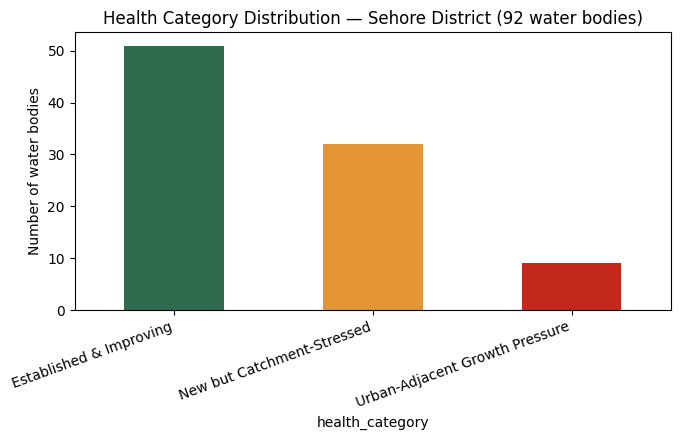

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors_map = {'Established & Improving': '#2E6B4F',
              'New but Catchment-Stressed': '#E49635',
              'Urban-Adjacent Growth Pressure': '#C4281B'}
counts = df['health_category'].value_counts()
bar_colors = [colors_map.get(c, '#888888') for c in counts.index]
counts.plot(kind='bar', ax=ax, color=bar_colors)
ax.set_ylabel('Number of water bodies')
ax.set_title('Health Category Distribution — Sehore District (92 water bodies)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../Images/health_category_chart.png', dpi=300)
plt.show()


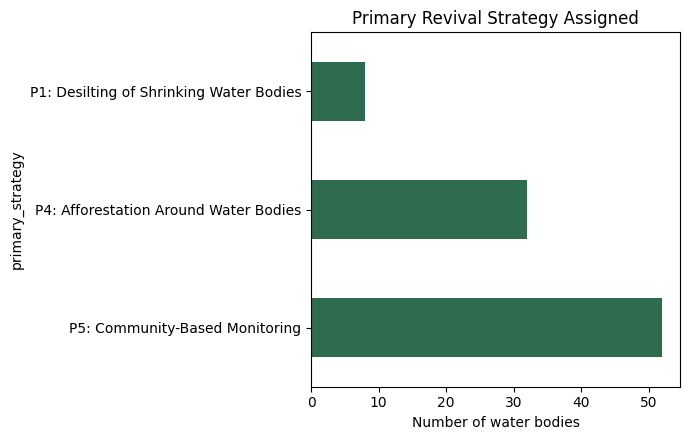

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
df['primary_strategy'].value_counts().plot(kind='barh', ax=ax, color='#2E6B4F')
ax.set_xlabel('Number of water bodies')
ax.set_title('Primary Revival Strategy Assigned')
plt.tight_layout()
plt.savefig('../Images/strategy_chart.png', dpi=300)
plt.show()


## 4. Build the PDF

In [7]:
styles = getSampleStyleSheet()
title_style = ParagraphStyle('TitleCustom', parent=styles['Title'],
                               fontSize=20, textColor=colors.HexColor('#1F4E37'),
                               alignment=TA_CENTER)
h2_style = ParagraphStyle('H2Custom', parent=styles['Heading2'],
                            textColor=colors.HexColor('#2E6B4F'))
body_style = styles['BodyText']
small_style = ParagraphStyle('Small', parent=styles['BodyText'], fontSize=8,
                               textColor=colors.grey)

def make_table(data, col_widths, header_fill='#1F4E37'):
    tbl = Table(data, colWidths=col_widths, repeatRows=1)
    tbl.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor(header_fill)),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('FONTSIZE', (0, 0), (-1, -1), 8),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
        ('VALIGN', (0, 0), (-1, -1), 'TOP'),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#F2F2F2')]),
    ]))
    return tbl


In [8]:
story = []

# ---- Title page ----
story.append(Spacer(1, 3*cm))
story.append(Paragraph("Water Body Health Card", title_style))
story.append(Paragraph("Sehore District, Madhya Pradesh", styles['Heading3']))
story.append(Spacer(1, 1*cm))
story.append(Paragraph(
    "Automated assessment generated from Sentinel-2 NDWI/NDVI time series, "
    "MODIS/Dynamic World land cover, and k-means health clustering "
    "(DSN3099 EPICS Project).", body_style))
story.append(PageBreak())

# ---- Executive summary ----
story.append(Paragraph("Executive Summary", h2_style))
story.append(Spacer(1, 12))

n_total = len(df)
n_urgent = (df['priority_rank'] == 1).sum()
n_established = (df['health_category'] == 'Established & Improving').sum()
n_new = df['is_new_since_2017'].sum()

summary_text = (
    f"A total of {n_total} distinct water bodies were identified and assessed "
    f"across Sehore district using multi-temporal satellite imagery (2017-2024). "
    f"Of these, {n_established} ({n_established/n_total*100:.0f}%) are classified as "
    f"'Established &amp; Improving', {n_new} ({n_new/n_total*100:.0f}%) are new "
    f"since 2017, and {n_urgent} water bodies show a net decline in surface water "
    f"area and are flagged as urgent priority for desilting intervention."
)
story.append(Paragraph(summary_text, body_style))
story.append(Spacer(1, 20))

story.append(Image('health_category_chart.png', width=14*cm, height=9*cm))
story.append(Spacer(1, 12))
story.append(Image('strategy_chart.png', width=14*cm, height=9*cm))
story.append(PageBreak())


In [9]:
# ---- Priority Tier 1: Urgent, full narrative cards ----
story.append(Paragraph("Priority Tier 1 — Urgent (Net Water Loss)", h2_style))
story.append(Paragraph(
    "These water bodies show a net decline in surface water area since 2017, "
    "despite in some cases sitting within an otherwise stable cluster average. "
    "These are the strongest candidates for field verification and immediate "
    "desilting intervention.", body_style))
story.append(Spacer(1, 12))

urgent_df = df[df['priority_rank'] == 1].sort_values('water_pct_change_capped')

for _, row in urgent_df.iterrows():
    story.append(Paragraph(f"Water Body {row['water_body_id'][-6:]}", styles['Heading4']))
    story.append(Paragraph(row['narrative'], body_style))
    story.append(Spacer(1, 10))

story.append(PageBreak())


In [10]:
# ---- Priority Tiers 2 & 3: summarized tables ----
story.append(Paragraph("Priority Tier 2 — Multiple Compounding Pressures", h2_style))
tier2 = df[df['priority_rank'] == 2]
if len(tier2) > 0:
    data = [['ID', 'Area (ha)', 'Category', 'Primary Strategy', '# Strategies']]
    for _, r in tier2.iterrows():
        data.append([r['water_body_id'][-6:], f"{r['area_ha_2024']:.1f}",
                     r['health_category'], r['primary_strategy'], str(r['num_strategies'])])
    story.append(make_table(data, [2.2*cm, 2*cm, 4*cm, 6*cm, 2*cm]))
else:
    story.append(Paragraph("No water bodies in this tier.", body_style))

story.append(Spacer(1, 20))

story.append(Paragraph("Priority Tier 3 — Standard Monitoring", h2_style))
tier3 = df[df['priority_rank'] == 3]
data = [['ID', 'Area (ha)', 'Category', 'Primary Strategy']]
for _, r in tier3.iterrows():
    data.append([r['water_body_id'][-6:], f"{r['area_ha_2024']:.1f}",
                 r['health_category'], r['primary_strategy']])
story.append(make_table(data, [2.5*cm, 2.5*cm, 5*cm, 6*cm]))

story.append(PageBreak())


In [11]:
# ---- Methodology / limitations footnote ----
story.append(Paragraph("Methodology &amp; Limitations", h2_style))
methodology_text = """
Water body boundaries were derived from Sentinel-2 NDWI thresholding (2024) and
validated against 18 manually labeled ground-truth points near VIT Bhopal campus
(77.8% accuracy, kappa 0.48 for both the NDWI threshold and a Random Forest
classifier — no measurable difference at this sample size and location; results
should not be assumed to generalize district-wide). Catchment buffers were scaled
per water body (5x each body's own equivalent radius, clamped 100m-2000m) rather
than using a fixed buffer for all sites. Health categories were derived via k-means
clustering (k=3, chosen by silhouette score, not assumed in advance) on standardized
features including log-transformed area, capped water-area percent change, catchment
NDVI trend, and land-use composition. Strategy assignment combines cluster-level
defaults with individual per-water-body override rules. 31 of 92 water bodies
(34%) show near-zero detected water in 2017 and are treated as new construction
rather than assigned an unstable percent-change value.
"""
story.append(Paragraph(methodology_text, small_style))

doc = SimpleDocTemplate('../Sehore_Water_Body_Health_Card_Report.pdf', pagesize=A4,
                          topMargin=2*cm, bottomMargin=2*cm,
                          leftMargin=2*cm, rightMargin=2*cm)
doc.build(story)
print("Report saved: Sehore_Water_Body_Health_Card_Report.pdf")


OSError: 
fileName='health_category_chart.png' identity=[ImageReader@0x19c3148f0e0 filename='health_category_chart.png'] Cannot open resource "health_category_chart.png"

## 5. Optional: LLM-enhanced narrative (Insight Engine pattern)

Drop-in replacement for `generate_narrative()` above if you want richer, more
varied prose instead of the deterministic template. Requires your own Groq API
key (same pattern as Insight Engine). **Not run by default** — this cell is here
as a ready-to-use alternative, not part of the main pipeline above.


In [ ]:
# import os
# from groq import Groq
#
# client = Groq(api_key=os.environ.get('GROQ_API_KEY'))
#
# def generate_narrative_llm(row):
#     prompt = (
#         f"Write a 2-3 sentence professional summary for a water body health report. "
#         f"Area: {row['area_ha_2024']:.2f} ha. Category: {row['health_category']}. "
#         f"Water area change since 2017: {row['water_pct_change_capped']:.1f}%. "
#         f"Catchment NDVI change: {row['catchment_ndvi_change']:.3f}. "
#         f"Catchment cropland: {row['catchment_pct_cropland']:.0f}%, "
#         f"urban: {row['catchment_pct_urban']:.0f}%. "
#         f"Recommended strategy: {row['primary_strategy']}. "
#         f"Keep it factual and report-appropriate, no exclamation marks."
#     )
#     response = client.chat.completions.create(
#         model="llama-3.1-8b-instant",
#         messages=[{"role": "user", "content": prompt}],
#         max_tokens=150,
#         temperature=0.4
#     )
#     return response.choices[0].message.content.strip()
#
# To use: df['narrative'] = df.apply(generate_narrative_llm, axis=1)
# then re-run the PDF assembly cells above.
